# EDA: Telco Customer Churn

Цель этого анализа — не просто описать данные, а найти **конкретные, статистически подтверждённые рычаги удержания**, которые лягут в основу модели и последующей кампании.

**Датасет:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) — 7043 клиента телеком-компании, 21 признак  + целевая переменная `Churn`.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu


plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 30)

df = pd.read_csv('telco.csv')
df.shape

(7043, 21)

## 1. Качество данных

`TotalCharges` читается как строка (`object`), а не число.

In [36]:
print(df.dtypes.value_counts())
print()
print("Пропуски по столбцам:")
print((df['TotalCharges'].astype(str).str.strip() == '').sum(), "строк с пустым TotalCharges")

str        18
int64       2
float64     1
Name: count, dtype: int64

Пропуски по столбцам:
11 строк с пустым TotalCharges


11 строк имеют пустое значение `TotalCharges` вместо числа. Проверим, что их объединяет, прежде чем просто удалять или заполнять нулём.

In [37]:
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print(df.loc[blank_mask, ['tenure', 'MonthlyCharges', 'Churn']])

      tenure  MonthlyCharges Churn
488        0           52.55    No
753        0           20.25    No
936        0           80.85    No
1082       0           25.75    No
1340       0           56.05    No
3331       0           19.85    No
3826       0           25.35    No
4380       0           20.00    No
5218       0           19.70    No
6670       0           73.35    No
6754       0           61.90    No


Проверка, что это не совпадение

In [38]:
blank_mask = df['tenure'].astype(str).str.strip() == 0
print(df.loc[blank_mask, ['tenure', 'MonthlyCharges', 'Churn']])

Empty DataFrame
Columns: [tenure, MonthlyCharges, Churn]
Index: []


Все 11 клиентов с пустым `TotalCharges` имеют `tenure = 0`, то есть это клиенты, подключившиеся буквально в день выгрузки данных — у них ещё не сформировался ни один платёж. 
Нужно задать `TotalCharges = 0` для этих строк, а не удалять клиентов из выборки.

In [39]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[blank_mask, 'TotalCharges'] = 0
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)
df['TotalCharges'].isna().sum()

np.int64(11)

## 2. Общая картина оттока

Общий churn rate: 26.5%


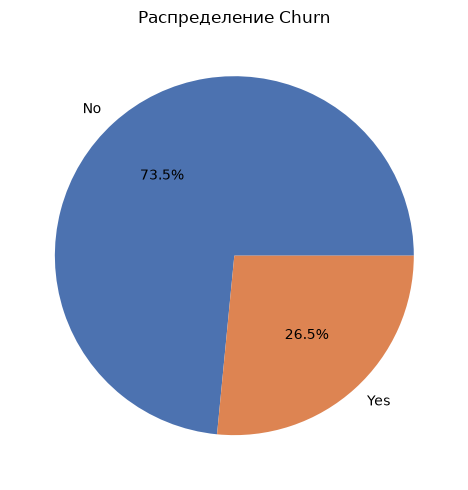

In [40]:
churn_rate = df['ChurnFlag'].mean()
print(f"Общий churn rate: {churn_rate:.1%}")

fig, ax = plt.subplots(figsize=(5,5))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], ax=ax, ylabel='')
ax.set_title('Распределение Churn')
plt.tight_layout()
plt.savefig('chart_churn_overall.png', dpi=110)
plt.show()

26.5% клиентов в выборке ушли.

## 3. Churn rate по ключевым срезам

Смотрим на **долю ушедших внутри категории** 

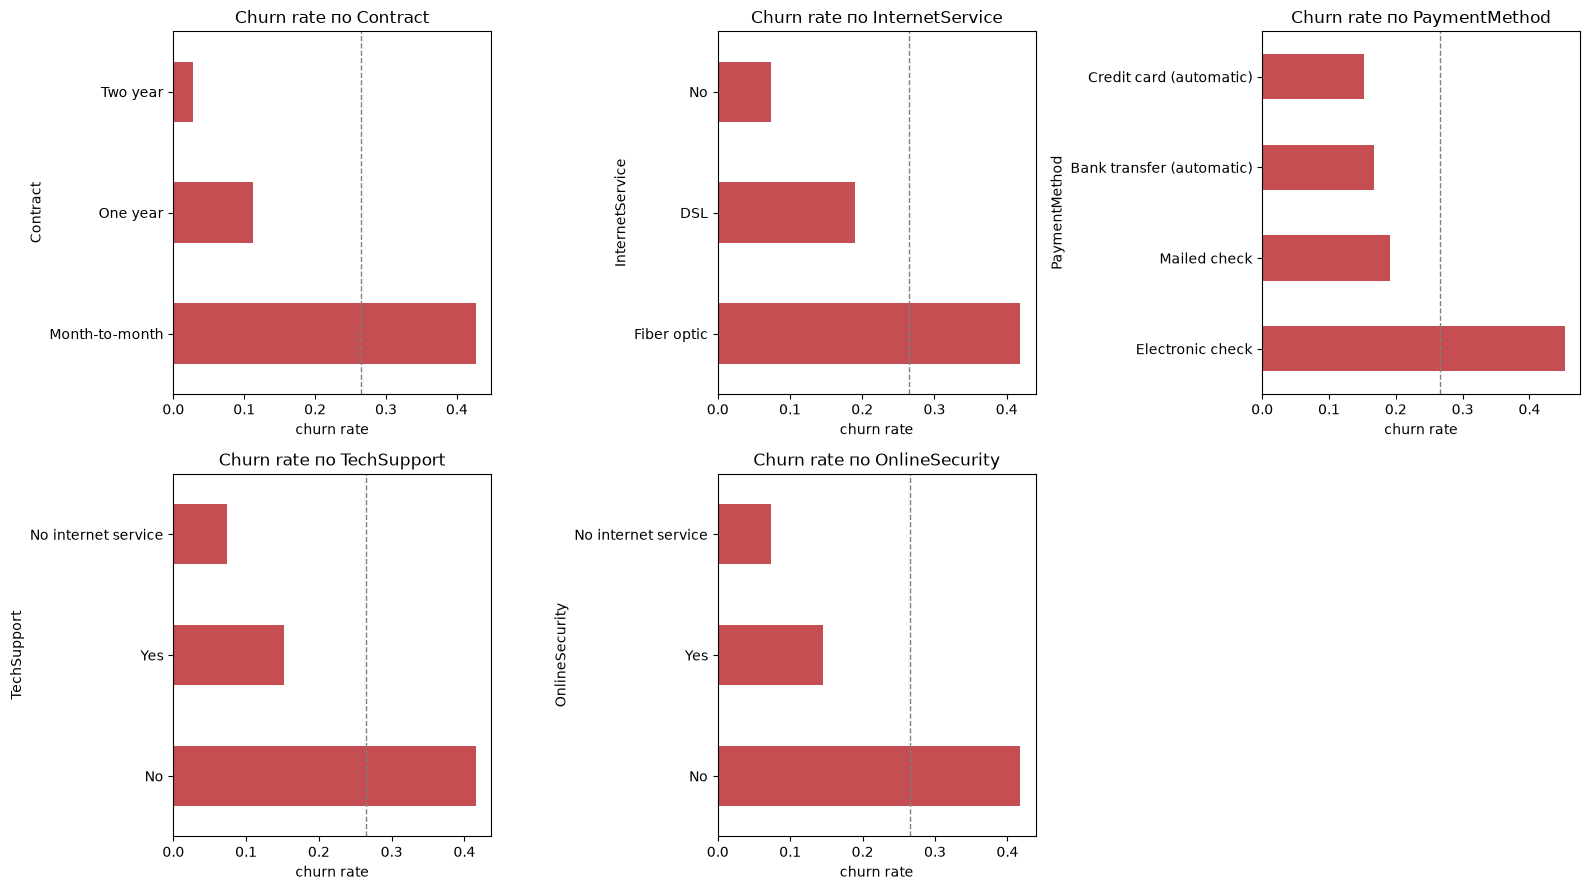

=== Contract ===
                churn_rate  n_clients
Contract                             
Month-to-month       0.427       3875
One year             0.113       1473
Two year             0.028       1695

=== InternetService ===
                 churn_rate  n_clients
InternetService                       
Fiber optic           0.419       3096
DSL                   0.190       2421
No                    0.074       1526

=== PaymentMethod ===
                           churn_rate  n_clients
PaymentMethod                                   
Electronic check                0.453       2365
Mailed check                    0.191       1612
Bank transfer (automatic)       0.167       1544
Credit card (automatic)         0.152       1522

=== TechSupport ===
                     churn_rate  n_clients
TechSupport                               
No                        0.416       3473
Yes                       0.152       2044
No internet service       0.074       1526

=== OnlineSecurity 

In [41]:
def churn_rate_by(col):
    s = df.groupby(col)['ChurnFlag'].agg(['mean', 'count']).round(3)
    s.columns = ['churn_rate', 'n_clients']
    return s.sort_values('churn_rate', ascending=False)

key_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    tab = churn_rate_by(col)
    tab['churn_rate'].plot.barh(ax=axes[i], color='#C44E52')
    axes[i].set_title(f'Churn rate по {col}')
    axes[i].set_xlabel('churn rate')
    axes[i].axvline(churn_rate, color='gray', linestyle='--', linewidth=1)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('chart_breakdown.png', dpi=110)
plt.show()

for col in key_cols:
    print(f"=== {col} ===")
    print(churn_rate_by(col))
    print()

**Ключевые наблюдения (пунктирная линия на графиках — средний churn rate 26.5%):**

- **Contract** — самый сильный сигнал в датасете: Month-to-month — 42.7% churn, One year — 11.3%, Two year — всего 2.8%. Разница в 15 раз между крайними категориями.
- **PaymentMethod** — Electronic check выделяется резко: 45.3% churn против 15–19% у остальных способов оплаты. Похоже на прокси для менее вовлечённого / менее "привязанного" клиента (автоплатёж обычно означает больше доверия и меньше трения при продлении).
- **InternetService** — у Fiber optic churn почти в 2 раза выше, чем у DSL (41.9% vs 19.0%), и в 5.7 раза выше, чем у клиентов без интернета вообще. Это контринтуитивно (более дорогая и качественная услуга — выше отток) и заслуживает отдельного объяснения (см. раздел 7).
- **TechSupport / OnlineSecurity** — отсутствие этих доп.услуг почти утраивает churn rate (41–42% против 14–15%). Это одни из самых сильных кандидатов на "рычаги удержания", потому что ими можно управлять напрямую (предложить бесплатный месяц поддержки), в отличие от, например, демографии.

## 4. Числовые признаки: tenure, MonthlyCharges, TotalCharges

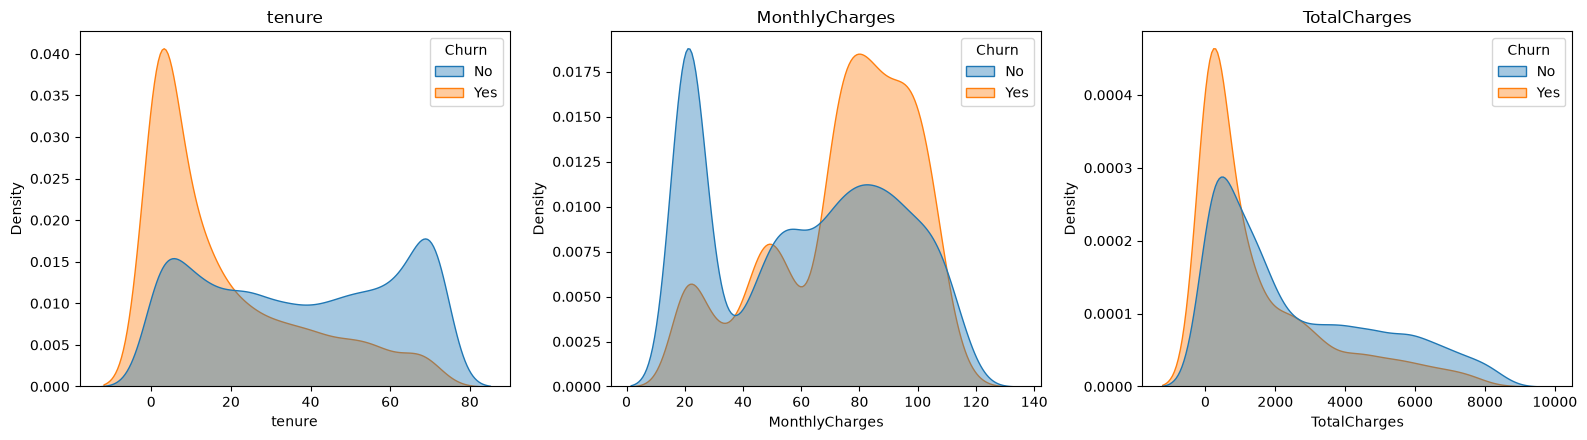

tenure: медиана(Churn)=10.0, медиана(Stay)=38.0, Mann-Whitney p=2.42e-208
MonthlyCharges: медиана(Churn)=79.7, медиана(Stay)=64.4, Mann-Whitney p=3.31e-54
TotalCharges: медиана(Churn)=703.5, медиана(Stay)=1683.6, Mann-Whitney p=nan


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, alpha=0.4, ax=ax) #график ядерной оценки плотности
    ax.set_title(col)
plt.tight_layout()
plt.savefig('chart_numeric_dist.png', dpi=110)
plt.show()

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    a = df[df.Churn == 'Yes'][col]
    b = df[df.Churn == 'No'][col]
    stat, p = mannwhitneyu(a, b)#U-критерий Манна-Уитни.Это непараметрический статистический тест, который используется для проверки того, различаются ли распределения двух независимых выборок
    print(f"{col}: медиана(Churn)={a.median():.1f}, медиана(Stay)={b.median():.1f}, Mann-Whitney p={p:.2e}")

**Наблюдения:**
- **Tenure** — самое явное различие: ушедшие клиенты имеют медианный "стаж" 10 месяцев против 38 у оставшихся. Отток концентрируется в первый год жизни клиента.
- **MonthlyCharges** — ушедшие клиенты платят *больше* (медиана 79.7 против 64.4). На первый взгляд странно (обычно дороже = ценнее клиент), ндорогой тариф без сопровождающих услуг поддержки оказывается менее "липким", а не более.
- **TotalCharges** — ожидаемо ниже у ушедших, но это в значительной степени математическое следствие короткого tenure, а не самостоятельный сигнал.

Все три различия статистически значимы (p ≈ 0), но для tenure и MonthlyCharges это ещё и содержательно интерпретируемые эффекты.

## 5. Статистическая проверка гипотез 
Визуальные различия в разделе 3 нужно подтвердить статистически, чтобы отделить реальные закономерности от шума выборки.

In [ ]:
results = []
for col in ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity',
            'Dependents', 'Partner', 'PaperlessBilling', 'SeniorCitizen', 'gender']:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, exp = chi2_contingency(ct) #chi2 (Хи-квадрат статистика). Чем оно больше, тем сильнее связь между переменными
    results.append({'feature': col, 'chi2': round(chi2, 1), 'p_value': p,
                     'significant (p<0.01)': p < 0.01})

chi_df = pd.DataFrame(results).sort_values('chi2', ascending=False)
chi_df

,feature,chi2,p_value,significant (p<0.01)
0,Contract,1184.6,5.863038e-258,True
4,OnlineSecurity,850.0,2.661150e-185,True
3,TechSupport,828.2,1.443084e-180,True
2,InternetService,732.3,9.571788e-160,True
1,PaymentMethod,648.1,3.682355e-140,True
7,PaperlessBilling,258.3,4.073355e-58,True
5,Dependents,189.1,4.924922e-43,True
8,SeniorCitizen,159.4,1.510067e-36,True
6,Partner,158.7,2.139911e-36,True
9,gender,0.5,4.865787e-01,False


**Вывод:** практически все признаки, кроме `gender`, статистически значимо связаны с оттоком (p < 0.01). `gender` — единственный признак без значимой связи, что ожидаемо и хорошо согласуется со здравым смыслом (пол не должен влиять на решение расторгнуть контракт с телеком-провайдером).

## 6. Сегментация клиентов по tenure и типу контракта

Вместо кластеризации ради кластеризации, построим понятную бизнесу сегментацию: как меняется риск оттока в зависимости от "возраста" клиента внутри каждого типа контракта.

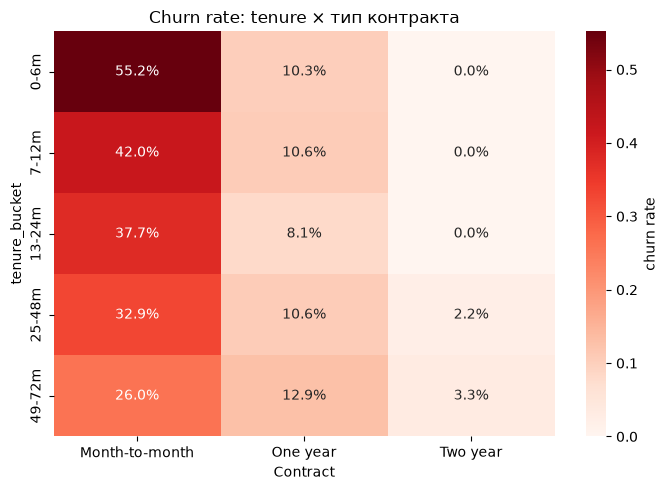

Contract,Month-to-month,One year,Two year
tenure_bucket,,,
0-6m,0.552,0.103,0.000
7-12m,0.420,0.106,0.000
13-24m,0.377,0.081,0.000
25-48m,0.329,0.106,0.022
49-72m,0.260,0.129,0.033


In [44]:
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, 72],
                             labels=['0-6m', '7-12m', '13-24m', '25-48m', '49-72m'])

pivot = pd.crosstab(df['tenure_bucket'], df['Contract'],
                     values=df['ChurnFlag'], aggfunc='mean')

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='Reds', ax=ax, cbar_kws={'label': 'churn rate'})
ax.set_title('Churn rate: tenure × тип контракта')
plt.tight_layout()
plt.savefig('chart_segmentation_heatmap.png', dpi=110)
plt.show()
pivot.round(3)

**Инсайт:** риск оттока максимален (55.2%) у совсем новых клиентов (0–6 месяцев) на месячном контракте — и полностью отсутствует (0%) у новых клиентов на двухлетнем контракте. Тип контракта "гасит" эффект новизны почти полностью: даже свежий клиент на длинном контракте почти не уходит. Это говорит о том, что тип контракта — не просто коррелят, а, вероятно, структурный барьер выхода (exit barrier), а не просто маркер вовлечённости.

## 7. Поиск взаимодействий признаков

В разделе 3 отток у Fiber optic оказался неожиданно высоким. Проверим, не объясняется ли это отсутствием сопутствующей технической поддержки, а не самой технологией.

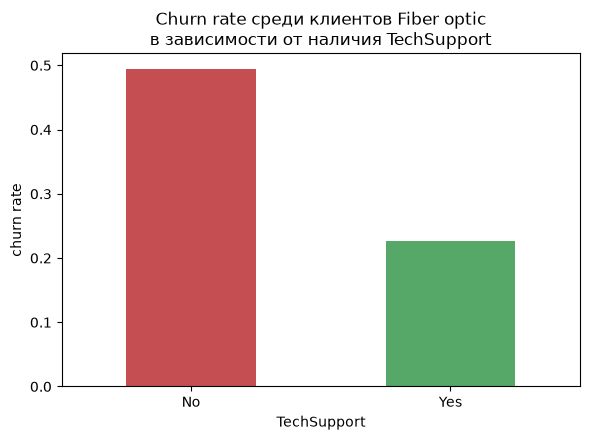

,churn_rate,n_clients
TechSupport,,
No,0.494,2230
Yes,0.226,866


In [45]:
fiber = df[df.InternetService == 'Fiber optic']
interaction = fiber.groupby('TechSupport')['ChurnFlag'].agg(['mean', 'count']).round(3)
interaction.columns = ['churn_rate', 'n_clients']

fig, ax = plt.subplots(figsize=(6, 4.5))
interaction['churn_rate'].plot.bar(ax=ax, color=['#C44E52', '#55A868'])
ax.set_title('Churn rate среди клиентов Fiber optic\nв зависимости от наличия TechSupport')
ax.set_ylabel('churn rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_interaction.png', dpi=110)
plt.show()
interaction

**Инсайт:** среди клиентов на Fiber optic churn rate падает более чем вдвое — с 49.4% до 22.6% — при наличии технической поддержки. То есть проблема не в самом Fiber optic как продукте, а в клиентском опыте без сопровождения: вероятно, более сложная и капризная в быту технология требует поддержки, а её отсутствие резко увеличивает фрустрацию и уход. Это меняет практическую рекомендацию: не "чинить" Fiber optic как продукт, а **бандлить его с бесплатным пробным периодом TechSupport**.

## 8. Сегмент максимального риска — ключевой инсайт

Объединим три самых сильных найденных фактора (Contract, InternetService, TechSupport) в одну группу и оценим её вес в общей картине оттока.

In [46]:
high_risk = df[(df.Contract == 'Month-to-month') &
               (df.InternetService == 'Fiber optic') &
               (df.TechSupport == 'No')]

low_risk = df[(df.Contract != 'Month-to-month') & (df.TechSupport == 'Yes')]

summary = pd.DataFrame({
    'Сегмент максимального риска\n(M2M + Fiber + без TechSupport)': [
        len(high_risk), f"{len(high_risk)/len(df):.1%}",
        f"{high_risk.ChurnFlag.mean():.1%}",
        f"{high_risk.ChurnFlag.sum()/df.ChurnFlag.sum():.1%}",
        f"${high_risk.MonthlyCharges.sum():,.0f}"
    ],
    'Сегмент минимального риска\n(долгий контракт + TechSupport)': [
        len(low_risk), f"{len(low_risk)/len(df):.1%}",
        f"{low_risk.ChurnFlag.mean():.1%}",
        f"{low_risk.ChurnFlag.sum()/df.ChurnFlag.sum():.1%}",
        f"${low_risk.MonthlyCharges.sum():,.0f}"
    ]
}, index=['Число клиентов', 'Доля от всей базы', 'Churn rate', 'Доля от всех ушедших', 'Месячная выручка сегмента'])
summary

,Сегмент максимального риска\n(M2M + Fiber + без TechSupport),Сегмент минимального риска\n(долгий контракт + TechSupport)
Число клиентов,1796,1373
Доля от всей базы,25.5%,19.5%
Churn rate,57.5%,7.6%
Доля от всех ушедших,55.3%,5.6%
Месячная выручка сегмента,"$153,547","$113,845"


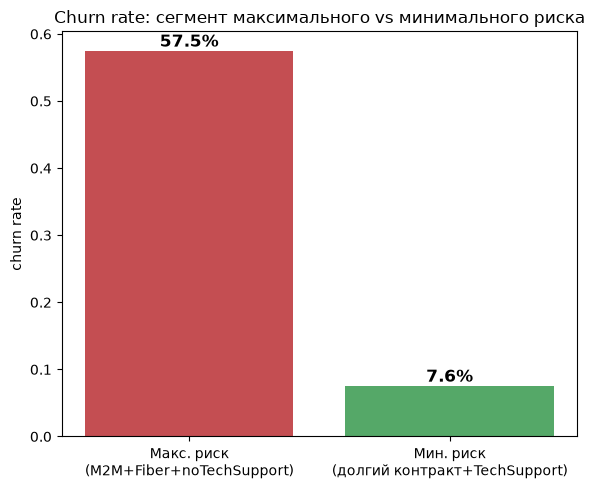

In [47]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Макс. риск\n(M2M+Fiber+noTechSupport)', 'Мин. риск\n(долгий контракт+TechSupport)'],
              [high_risk.ChurnFlag.mean(), low_risk.ChurnFlag.mean()],
              color=['#C44E52', '#55A868'])
ax.set_ylabel('churn rate')
ax.set_title('Churn rate: сегмент максимального vs минимального риска')
for b in bars:
    ax.annotate(f'{b.get_height():.1%}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_risk_segments.png', dpi=110)
plt.show()

**Главный инсайт всего анализа:** сегмент клиентов на месячном контракте с Fiber optic и без технической поддержки составляет **25.5% всей базы**, но даёт **55.3% всех случаев оттока** при churn rate **57.5%**. Для сравнения — "безопасный" сегмент (длинный контракт + техподдержка) почти не теряет клиентов (7.6%).

Это не просто описательная статистика — это готовый **таргет-лист для retention-кампании**: даже без модели машинного обучения, просто ориентируясь на пересечение этих трёх признаков, можно сфокусировать бюджет удержания на четверти базы, которая отвечает за больше половины оттока.

## 9. Executive Summary

**Итоговые инсайты для перехода к моделированию:**

1. **Contract — самый сильный предиктор** (churn 42.7% → 11.3% → 2.8% при переходе Month-to-month → One year → Two year). Ожидаемо будет топ-1 признаком по важности в модели.
2. **Отток концентрируется в первые 6–12 месяцев жизни клиента** (медианный tenure ушедших — 10 месяцев). Указывает на проблему в раннем клиентском опыте / онбординге, а не на постепенное "выгорание" лояльности.
3. **Отсутствие TechSupport и OnlineSecurity почти утраивает риск оттока**, и в отличие от демографических признаков, это управляемые рычаги — можно предлагать как часть retention-оффера.
4. **Высокий отток у Fiber optic — это эффект отсутствия поддержки, а не самого продукта**: наличие TechSupport вдвое снижает churn внутри этого сегмента.
5. **Electronic check как способ оплаты — прокси-сигнал низкой вовлечённости** (45.3% churn), вероятно стоит поощрять переход на автоплатёж как микро-действие удержания.
6. **Найден компактный сегмент максимального риска** (M2M + Fiber + без TechSupport): 25.5% базы → 55.3% всего оттока. Это прямой кандидат в таргет-лист для пилотной retention-кампании ещё до построения ML-модели.

**Гипотезы для проверки на этапе моделирования:**
- Contract, tenure, TechSupport, InternetService и PaymentMethod должны войти в топ признаков по SHAP-важности.
- Стоит явно сконструировать feature-взаимодействие `InternetService × TechSupport` — судя по разделу 7, модель может недооценить эту связь, если признаки останутся независимыми one-hot колонками.
- Uplift-модель имеет смысл тестировать в первую очередь на сегменте месячных контрактов 0–12 месяцев tenure — там сосредоточен основной "спасаемый" отток.
